## 🤚 Hand Gesture Classification

Given *tabular data about four hand gestures*, let's try to classify the **gesture** of a given example.

We will use a TensorFlow ANN to make our predictions.

Data source: https://www.kaggle.com/datasets/kyr7plus/emg-4

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
dfs = []

for label in ['0', '1', '2', '3']:
    dfs.append(pd.read_csv('archive/' + label + '.csv'))

In [3]:
dfs

[      26.0  4.0  5.0   8.0  -1.0  -13.0  -109.0  -66.0  -9.0  2.0  ...  -28.0  \
 0    -47.0 -6.0 -5.0  -7.0  13.0   -1.0    35.0  -10.0  10.0 -4.0  ...  -25.0   
 1    -19.0 -8.0 -8.0  -8.0 -21.0   -6.0   -79.0   12.0   0.0  5.0  ...  -83.0   
 2      2.0  3.0  0.0   2.0   0.0   22.0   106.0  -14.0 -16.0 -2.0  ...  -38.0   
 3      6.0  0.0  0.0  -2.0 -14.0   10.0   -51.0    5.0   7.0  0.0  ...   38.0   
 4     15.0 -5.0 -5.0 -15.0  12.0  -22.0   -38.0   36.0   9.0  6.0  ...  -26.0   
 ...    ...  ...  ...   ...   ...    ...     ...    ...   ...  ...  ...    ...   
 2904 -12.0  0.0  0.0  -7.0  -4.0   -3.0    -1.0   -5.0   4.0 -1.0  ...   12.0   
 2905  -9.0 -1.0 -2.0   1.0 -13.0  -14.0   -59.0   -4.0  -9.0  0.0  ...   20.0   
 2906   3.0 -2.0 -2.0   4.0  18.0   -5.0   -31.0    7.0  -3.0 -3.0  ...   34.0   
 2907  -2.0 -2.0 -2.0   1.0  -3.0  -17.0   -33.0  -13.0   3.0  2.0  ...   -4.0   
 2908   0.0 -2.0 -3.0  -2.0   2.0    5.0    18.0   -1.0  -5.0 -2.0  ...   -2.0   
 
       61.0  4

In [4]:
dfs[0]

,26.0,4.0,5.0,8.0,-1.0,-13.0,-109.0,-66.0,-9.0,2.0,...,-28.0,61.0,4.0.3,8.0.1,5.0.1,4.0.4,-7.0.1,-59.0,16.0,0
0,-47.0,-6.0,-5.0,-7.0,13.0,-1.0,35.0,-10.0,10.0,-4.0,...,-25.0,47.0,6.0,6.0,5.0,13.0,21.0,111.0,15.0,0
1,-19.0,-8.0,-8.0,-8.0,-21.0,-6.0,-79.0,12.0,0.0,5.0,...,-83.0,7.0,7.0,1.0,-8.0,7.0,21.0,114.0,48.0,0
2,2.0,3.0,0.0,2.0,0.0,22.0,106.0,-14.0,-16.0,-2.0,...,-38.0,-11.0,4.0,7.0,11.0,33.0,39.0,119.0,43.0,0
3,6.0,0.0,0.0,-2.0,-14.0,10.0,-51.0,5.0,7.0,0.0,...,38.0,-35.0,-8.0,2.0,6.0,-13.0,-24.0,-112.0,-69.0,0
4,15.0,-5.0,-5.0,-15.0,12.0,-22.0,-38.0,36.0,9.0,6.0,...,-26.0,5.0,6.0,6.0,11.0,5.0,30.0,-48.0,25.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2904,-12.0,0.0,0.0,-7.0,-4.0,-3.0,-1.0,-5.0,4.0,-1.0,...,12.0,-3.0,0.0,2.0,-1.0,-1.0,4.0,-30.0,-20.0,0
2905,-9.0,-1.0,-2.0,1.0,-13.0,-14.0,-59.0,-4.0,-9.0,0.0,...,20.0,-4.0,0.0,0.0,0.0,-21.0,-10.0,-14.0,-29.0,0
2906,3.0,-2.0,-2.0,4.0,18.0,-5.0,-31.0,7.0,-3.0,-3.0,...,34.0,-7.0,4.0,4.0,2.0,1.0,4.0,-55.0,-4.0,0
2907,-2.0,-2.0,-2.0,1.0,-3.0,-17.0,-33.0,-13.0,3.0,2.0,...,-4.0,0.0,3.0,0.0,5.0,9.0,8.0,-13.0,11.0,0


In [5]:
for df in dfs:
    df.columns = list(range(len(df.columns)))

In [7]:
dfs[2]

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,-1.0,12.0,20.0,7.0,20.0,-73.0,-4.0,-2.0,4.0,5.0,...,-3.0,-5.0,-2.0,0.0,-4.0,-7.0,5.0,6.0,9.0,2
1,4.0,5.0,-8.0,-2.0,10.0,-10.0,-10.0,16.0,-3.0,-18.0,...,2.0,0.0,2.0,3.0,-8.0,19.0,20.0,0.0,-8.0,2
2,-3.0,-3.0,5.0,11.0,25.0,-20.0,-2.0,14.0,9.0,32.0,...,15.0,-2.0,16.0,6.0,9.0,1.0,31.0,16.0,4.0,2
3,-5.0,-9.0,-2.0,-5.0,-46.0,-34.0,-9.0,-4.0,0.0,8.0,...,-5.0,-11.0,-6.0,7.0,6.0,-10.0,-24.0,-6.0,0.0,2
4,3.0,-3.0,-6.0,-5.0,-3.0,-4.0,-5.0,-4.0,-5.0,8.0,...,-18.0,-14.0,8.0,1.0,-2.0,-4.0,-34.0,-3.0,6.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2937,1.0,-14.0,-5.0,-9.0,-10.0,4.0,-3.0,-4.0,3.0,4.0,...,22.0,8.0,28.0,-3.0,8.0,22.0,35.0,-1.0,-11.0,2
2938,-3.0,-8.0,-7.0,-7.0,-18.0,-49.0,-5.0,9.0,23.0,0.0,...,-8.0,8.0,17.0,9.0,-9.0,-1.0,-6.0,0.0,7.0,2
2939,-13.0,3.0,-4.0,-1.0,-7.0,15.0,-4.0,-6.0,-4.0,-9.0,...,6.0,-3.0,18.0,-2.0,-9.0,-11.0,-9.0,-4.0,22.0,2
2940,8.0,-24.0,-11.0,-7.0,21.0,23.0,0.0,6.0,-22.0,-10.0,...,-7.0,19.0,38.0,7.0,3.0,6.0,-5.0,-2.0,7.0,2


In [10]:
data = pd.concat([df for df in dfs], axis=0).reset_index(drop=True)

In [11]:
data

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,-47.0,-6.0,-5.0,-7.0,13.0,-1.0,35.0,-10.0,10.0,-4.0,...,-25.0,47.0,6.0,6.0,5.0,13.0,21.0,111.0,15.0,0
1,-19.0,-8.0,-8.0,-8.0,-21.0,-6.0,-79.0,12.0,0.0,5.0,...,-83.0,7.0,7.0,1.0,-8.0,7.0,21.0,114.0,48.0,0
2,2.0,3.0,0.0,2.0,0.0,22.0,106.0,-14.0,-16.0,-2.0,...,-38.0,-11.0,4.0,7.0,11.0,33.0,39.0,119.0,43.0,0
3,6.0,0.0,0.0,-2.0,-14.0,10.0,-51.0,5.0,7.0,0.0,...,38.0,-35.0,-8.0,2.0,6.0,-13.0,-24.0,-112.0,-69.0,0
4,15.0,-5.0,-5.0,-15.0,12.0,-22.0,-38.0,36.0,9.0,6.0,...,-26.0,5.0,6.0,6.0,11.0,5.0,30.0,-48.0,25.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11669,-3.0,-1.0,-1.0,-1.0,-28.0,20.0,5.0,0.0,-5.0,0.0,...,-3.0,1.0,4.0,3.0,4.0,-51.0,-49.0,5.0,-9.0,3
11670,-13.0,-5.0,-4.0,-3.0,-4.0,-24.0,-10.0,-8.0,20.0,9.0,...,6.0,-3.0,-3.0,-3.0,-5.0,-4.0,-45.0,-12.0,-15.0,3
11671,-1.0,-3.0,-1.0,1.0,30.0,38.0,-1.0,36.0,-10.0,1.0,...,14.0,-8.0,-4.0,-4.0,-4.0,-21.0,-29.0,-5.0,0.0,3
11672,1.0,4.0,4.0,5.0,9.0,-10.0,4.0,1.0,-2.0,-1.0,...,-16.0,-3.0,0.0,-3.0,-5.0,-36.0,-90.0,3.0,5.0,3


In [13]:
print("Total missing values:", data.isna().sum().sum())

Total missing values: 0


#### Splitting/Scaling

In [14]:
y = data[64].copy()
X = data.drop(64, axis=1).copy()

In [15]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=100)

### Training

In [18]:
X_train.shape

(8171, 64)

In [19]:
inputs = tf.keras.layers.Input(shape=(X_train.shape[1],))
x = tf.keras.layers.Dense(1024, activation='relu')(inputs)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

batch_size = 32
epochs = 50

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau()
    ]
)

Epoch 1/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7075 - loss: 0.7219 - val_accuracy: 0.8924 - val_loss: 0.3448 - learning_rate: 0.0010
Epoch 2/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9087 - loss: 0.2715 - val_accuracy: 0.9070 - val_loss: 0.3007 - learning_rate: 0.0010
Epoch 3/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9351 - loss: 0.1797 - val_accuracy: 0.9089 - val_loss: 0.2798 - learning_rate: 0.0010
Epoch 4/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9585 - loss: 0.1180 - val_accuracy: 0.9156 - val_loss: 0.2824 - learning_rate: 0.0010
Epoch 5/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9564 - loss: 0.1284 - val_accuracy: 0.9266 - val_loss: 0.2519 - learning_rate: 0.0010
Epoch 6/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9702 - loss: 0.0859 - val_accuracy: 0.9211 - val_loss: 0.3239 - learning_rate: 0.0010
Epoch 7/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9751 - loss: 0.

### Results

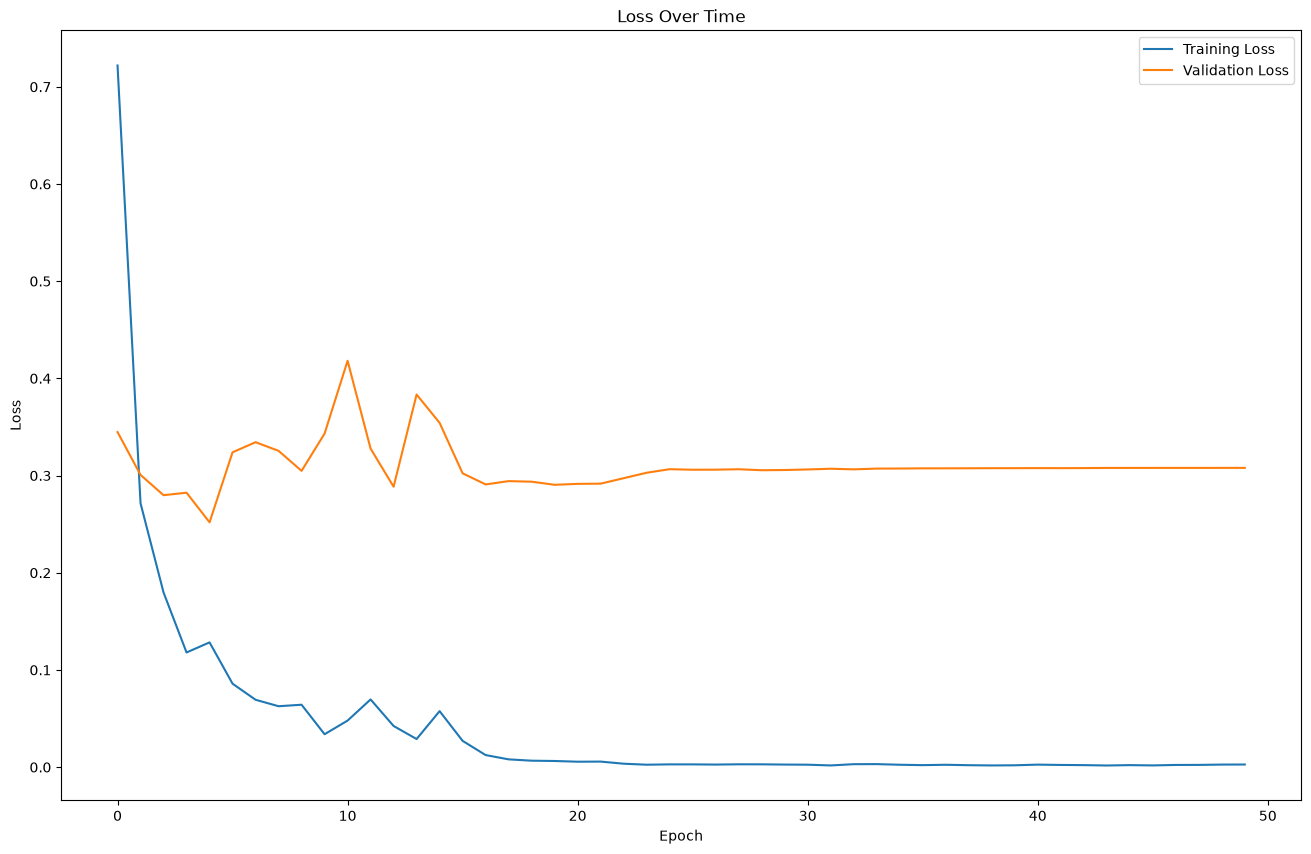

In [20]:
plt.figure(figsize=(16,10))

plt.plot(range(epochs), history.history['loss'], label='Training Loss')
plt.plot(range(epochs), history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Time')

plt.show()

In [38]:
model.evaluate(X_test, y_test)

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9492 - loss: 0.2017


[0.20167376101016998, 0.949186384677887]

In [39]:
y_true = np.array(y_test)
y_pred = model.predict(X_test)

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [40]:
y_pred = np.array(list(map(lambda x: np.argmax(x), y_pred)))

In [41]:
y_pred

array([2, 2, 1, ..., 2, 3, 0], shape=(3503,))

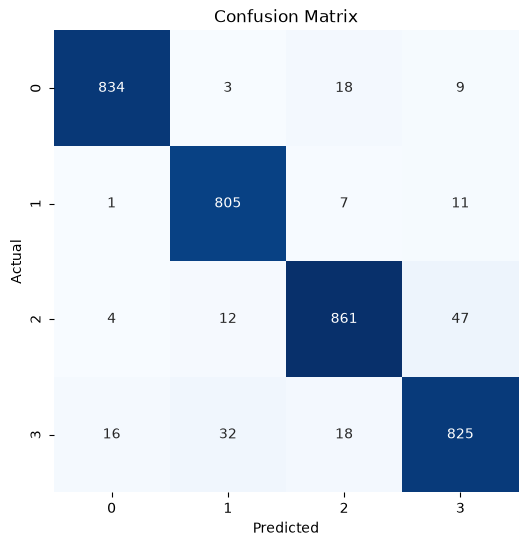

In [42]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [43]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       864
           1       0.94      0.98      0.96       824
           2       0.95      0.93      0.94       924
           3       0.92      0.93      0.93       891

    accuracy                           0.95      3503
   macro avg       0.95      0.95      0.95      3503
weighted avg       0.95      0.95      0.95      3503

